# Energy Consumption Anomaly Detection

**Objective:** Identify unusual energy intervals from demand, temperature, occupancy, reactive power, load factor, and peak ratio.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["demand_kwh", "temperature_c", "occupancy_pct", "reactive_kvarh", "load_factor", "peak_ratio"]
MEANS = np.asarray([420, 26, 68, 55, 0.72, 1.18], dtype=float)
STDS = np.asarray([58, 4, 12, 11, 0.08, 0.12], dtype=float)
SHIFTS = np.asarray([7, 2, -4, 6, -5, 7], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,demand_kwh,temperature_c,occupancy_pct,reactive_kvarh,load_factor,peak_ratio,scenario_anomaly
0,417.524,27.652,59.286,59.067,0.773,1.100,0
1,337.540,23.217,55.953,63.003,0.734,1.013,0
2,439.322,17.367,67.554,43.777,0.728,1.051,0
3,495.952,31.361,74.204,49.994,0.701,1.084,0
4,394.451,31.290,75.943,55.177,0.683,1.128,0


,count,mean,std,min,25%,50%,75%,max
demand_kwh,1000.0,435.922,98.518,241.764,384.357,422.861,462.125,912.466
temperature_c,1000.0,26.134,4.429,11.406,23.145,26.140,28.698,39.816
occupancy_pct,1000.0,65.601,15.257,3.640,57.851,67.152,75.068,106.895
reactive_kvarh,1000.0,58.052,16.745,20.785,48.308,55.407,64.330,140.409
load_factor,1000.0,0.705,0.110,0.220,0.661,0.716,0.769,0.982
peak_ratio,1000.0,1.211,0.209,0.653,1.098,1.190,1.268,2.133


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.2026


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,demand_kwh,temperature_c,occupancy_pct,reactive_kvarh,load_factor,peak_ratio,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
251,852.903,32.045,26.923,140.409,0.220,2.066,0.701,demand_kwh,10.960,1
388,767.315,30.736,24.377,104.189,0.374,1.900,0.690,demand_kwh,8.779,1
767,837.744,38.345,25.921,119.579,0.356,2.133,0.686,peak_ratio,11.138,1
561,795.179,30.766,21.478,130.761,0.329,1.929,0.686,demand_kwh,9.489,1
117,840.698,38.439,21.170,135.809,0.328,2.021,0.683,demand_kwh,10.649,1
569,898.498,34.452,14.881,123.483,0.299,1.928,0.682,demand_kwh,12.122,1
605,824.216,37.892,23.538,115.482,0.288,2.111,0.682,peak_ratio,10.879,1
792,912.466,31.350,11.687,115.209,0.315,2.079,0.681,demand_kwh,12.478,1
627,856.794,39.562,17.418,117.741,0.271,2.034,0.681,demand_kwh,11.059,1
505,902.919,35.246,16.068,132.661,0.305,2.029,0.680,demand_kwh,12.235,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.4266


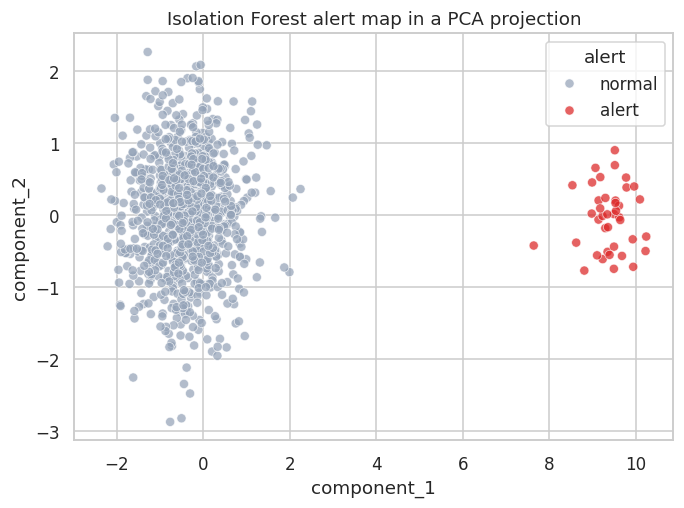

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
